# Dataset

In this homework, we continue using the fuel efficiency dataset. Download it from here.

You can do it with wget:

wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
The goal of this homework is to create a regression model for predicting the car fuel efficiency (column 'fuel_efficiency_mpg').

## Preparing the dataset
Preparation:

Fill missing values with zeros.
 * Do train/validation/test split with 60%/20%/20% distribution.
 * Use the train_test_split function and set the random_state parameter to 1.
 * Use DictVectorizer(sparse=True) to turn the dataframes into matrices.


In [37]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'

In [3]:
!wget $data -O data.csv

--2025-11-08 22:12:15--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 874188 (854K) [text/plain]
Saving to: ‘data.csv’

data.csv            100%[===================>] 853.70K  --.-KB/s    in 0.006s  

2025-11-08 22:12:15 (133 MB/s) - ‘data.csv’ saved [874188/874188]



In [4]:
df = pd.read_csv('data.csv')

In [5]:
df.head().T

,0,1,2,3,4
engine_displacement,170,130,170,220,210
num_cylinders,3.0,5.0,NaN,4.0,1.0
horsepower,159.0,97.0,78.0,NaN,140.0
vehicle_weight,3413.433759,3149.664934,3079.038997,2542.392402,3460.87099
acceleration,17.7,17.8,15.1,20.2,14.4
model_year,2003,2007,2018,2009,2009
origin,Europe,USA,Europe,USA,Europe
fuel_type,Gasoline,Gasoline,Gasoline,Diesel,Gasoline
drivetrain,All-wheel drive,Front-wheel drive,Front-wheel drive,All-wheel drive,All-wheel drive
num_doors,0.0,0.0,0.0,2.0,2.0


In [6]:
df.shape

(9704, 11)

In [7]:
df.isnull().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

In [8]:
df.dtypes

engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                  object
fuel_type               object
drivetrain              object
num_doors              float64
fuel_efficiency_mpg    float64
dtype: object

In [9]:
missing_columns = ['num_cylinders', 'horsepower', 'acceleration', 'num_doors']

In [10]:
for col in missing_columns:
    df[col] = df[col].fillna(0)

In [11]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [12]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [13]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [14]:
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [15]:
from sklearn.feature_extraction import DictVectorizer

In [16]:
train_dicts = df_train.to_dict(orient='records')

In [17]:
dv = DictVectorizer(sparse=False)

In [18]:
X_train = dv.fit_transform(train_dicts)

# Question 1
Let's train a decision tree regressor to predict the fuel_efficiency_mpg variable.

* Train a model with max_depth=1.

Which feature is used for splitting the data?

* 'vehicle_weight'
* 'model_year'
* 'origin'
* 'fuel_type'

In [19]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_text

In [20]:
dt = DecisionTreeRegressor(max_depth=1)

In [21]:
dt.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [30]:
print(export_text(dt, feature_names=list(dv.get_feature_names_out())))

|--- vehicle_weight <= 3022.11
|   |--- value: [16.88]
|--- vehicle_weight >  3022.11
|   |--- value: [12.94]



Ans: vechicle_weight

# Question 2

Train a random forest regressor with these parameters:

* `n_estimators=10`
* `random_state=1`
* `n_jobs=-1` (optional - to make training faster)


What's the RMSE of this model on the validation data?

* 0.045
* 0.45
* 4.5
* 45.0

In [23]:
from sklearn.ensemble import RandomForestRegressor

In [24]:
rf = RandomForestRegressor(n_estimators=10, random_state=1, n_jobs=-1)
rf.fit(X_train, y_train)

,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
val_dicts = df_val.to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [32]:
y_pred = rf.predict(X_val)

In [27]:
y_pred

array([18.62889858, 15.29598647, 18.22879442, ..., 14.80283652,
       13.49358341, 15.99288211], shape=(1941,))

In [29]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_val, y_pred)
print("RMSE:", rmse)

RMSE: 0.4599777557336148


# Question 3

Now let's experiment with the `n_estimators` parameter

* Try different values of this parameter from 10 to 200 with step 10.
* Set `random_state` to `1`.
* Evaluate the model on the validation dataset.


After which value of `n_estimators` does RMSE stop improving?
Consider 3 decimal places for calculating the answer.

- 10
- 25
- 80
- 200

If it doesn't stop improving, use the latest iteration number in
your answer.

In [39]:
scores = []

for n in range(10, 201, 10):
    rf = RandomForestRegressor(n_estimators=n, random_state=1)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)
    
    scores.append((n, rmse))
    print(f"n_estimators={n}, RMSE={rmse:.3f}")

n_estimators=10, RMSE=0.460
n_estimators=20, RMSE=0.454
n_estimators=30, RMSE=0.451
n_estimators=40, RMSE=0.448
n_estimators=50, RMSE=0.446
n_estimators=60, RMSE=0.445
n_estimators=70, RMSE=0.445
n_estimators=80, RMSE=0.445
n_estimators=90, RMSE=0.445
n_estimators=100, RMSE=0.444
n_estimators=110, RMSE=0.443
n_estimators=120, RMSE=0.444
n_estimators=130, RMSE=0.443
n_estimators=140, RMSE=0.443
n_estimators=150, RMSE=0.443
n_estimators=160, RMSE=0.443
n_estimators=170, RMSE=0.443
n_estimators=180, RMSE=0.442
n_estimators=190, RMSE=0.443
n_estimators=200, RMSE=0.443


In [35]:
df_scores = pd.DataFrame(scores, columns=['n_estimators', 'rmse'])

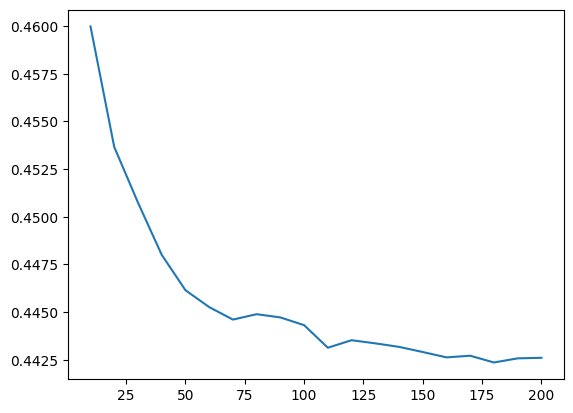

In [38]:
plt.plot(df_scores.n_estimators, df_scores.rmse)

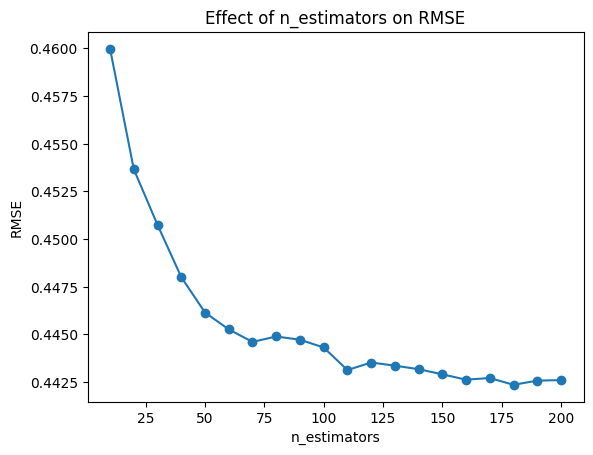

In [42]:
plt.plot(df_scores.n_estimators, df_scores.rmse, marker='o')
plt.xlabel("n_estimators")
plt.ylabel("RMSE")
plt.title("Effect of n_estimators on RMSE")
plt.show()

# Question 4

Let's select the best `max_depth`:

* Try different values of `max_depth`: `[10, 15, 20, 25]`
* For each of these values,
  * try different values of `n_estimators` from 10 till 200 (with step 10)
  * calculate the mean RMSE 
* Fix the random seed: `random_state=1`


What's the best `max_depth`, using the mean RMSE?

* 10
* 15
* 20
* 25

In [45]:
scores = []

for d in [10, 15, 20, 25]:
    for n in range(10, 201, 10):
        rf = RandomForestRegressor(n_estimators=n, random_state=1)
        rf.fit(X_train, y_train)
    
        y_pred = rf.predict(X_val)
        rmse = root_mean_squared_error(y_val, y_pred)
        
        scores.append((d, n, rmse))
        print(f"max_depth={d}, n_estimators={n}, RMSE={rmse:.3f}")

max_depth=10, n_estimators=10, RMSE=0.460
max_depth=10, n_estimators=20, RMSE=0.454
max_depth=10, n_estimators=30, RMSE=0.451
max_depth=10, n_estimators=40, RMSE=0.448
max_depth=10, n_estimators=50, RMSE=0.446
max_depth=10, n_estimators=60, RMSE=0.445
max_depth=10, n_estimators=70, RMSE=0.445
max_depth=10, n_estimators=80, RMSE=0.445
max_depth=10, n_estimators=90, RMSE=0.445
max_depth=10, n_estimators=100, RMSE=0.444
max_depth=10, n_estimators=110, RMSE=0.443
max_depth=10, n_estimators=120, RMSE=0.444
max_depth=10, n_estimators=130, RMSE=0.443
max_depth=10, n_estimators=140, RMSE=0.443
max_depth=10, n_estimators=150, RMSE=0.443
max_depth=10, n_estimators=160, RMSE=0.443
max_depth=10, n_estimators=170, RMSE=0.443
max_depth=10, n_estimators=180, RMSE=0.442
max_depth=10, n_estimators=190, RMSE=0.443
max_depth=10, n_estimators=200, RMSE=0.443
max_depth=15, n_estimators=10, RMSE=0.460
max_depth=15, n_estimators=20, RMSE=0.454
max_depth=15, n_estimators=30, RMSE=0.451
max_depth=15, n_estimat

In [46]:
scores

[(10, 10, 0.4599777557336148),
 (10, 20, 0.45365906507838477),
 (10, 30, 0.45074274602790043),
 (10, 40, 0.4480067936304668),
 (10, 50, 0.44615128055079933),
 (10, 60, 0.4452658337959235),
 (10, 70, 0.4446098249138531),
 (10, 80, 0.44489319803906885),
 (10, 90, 0.4447241129599527),
 (10, 100, 0.4443178455925074),
 (10, 110, 0.4431350090653453),
 (10, 120, 0.4435285723898764),
 (10, 130, 0.4433641780708843),
 (10, 140, 0.4431801001185647),
 (10, 150, 0.4429098757170559),
 (10, 160, 0.4426293654180784),
 (10, 170, 0.4427157028806333),
 (10, 180, 0.4423616814462061),
 (10, 190, 0.4425785032007027),
 (10, 200, 0.44260685365230207),
 (15, 10, 0.4599777557336148),
 (15, 20, 0.45365906507838477),
 (15, 30, 0.45074274602790043),
 (15, 40, 0.4480067936304668),
 (15, 50, 0.44615128055079933),
 (15, 60, 0.4452658337959235),
 (15, 70, 0.4446098249138531),
 (15, 80, 0.44489319803906885),
 (15, 90, 0.4447241129599527),
 (15, 100, 0.4443178455925074),
 (15, 110, 0.4431350090653453),
 (15, 120, 0.4435

In [50]:
# Convert to DataFrame
scores_df = pd.DataFrame(scores, columns=['max_depth', 'n_estimators', 'rmse'])

# Calculate mean RMSE for each max_depth
mean_rmse_by_depth = scores_df.groupby('max_depth')['rmse'].mean().round(4).reset_index()

print(mean_rmse_by_depth)


   max_depth    rmse
0         10  0.4456
1         15  0.4456
2         20  0.4456
3         25  0.4456


# Question 5

We can extract feature importance information from tree-based models. 

At each step of the decision tree learning algorithm, it finds the best split. 
When doing it, we can calculate "gain" - the reduction in impurity before and after the split. 
This gain is quite useful in understanding what are the important features for tree-based models.

In Scikit-Learn, tree-based models contain this information in the
[`feature_importances_`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html#sklearn.ensemble.RandomForestRegressor.feature_importances_)
field. 

For this homework question, we'll find the most important feature:

* Train the model with these parameters:
  * `n_estimators=10`,
  * `max_depth=20`,
  * `random_state=1`,
  * `n_jobs=-1` (optional)
* Get the feature importance information from this model


What's the most important feature (among these 4)? 

* `vehicle_weight`
*	`horsepower`
* `acceleration`
* `engine_displacement`	

